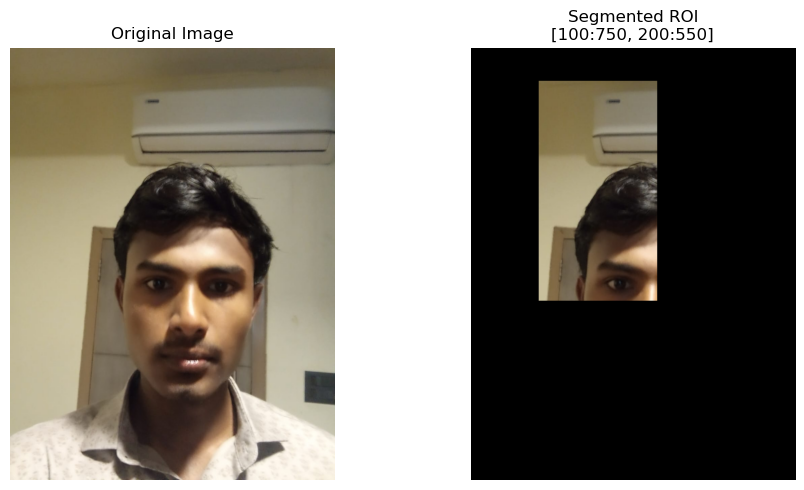

  ROI Segmentation Completed
  Image size: 960x1280
  ROI size: 350x650


In [18]:
# Install required packages (run once if needed)
# !pip install opencv-python-headless matplotlib numpy

import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import os

# Enable inline plotting for Jupyter
%matplotlib inline

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Read the image and convert to RGB
# For demo, create a sample image if 'myimage.png' doesn't exist
if not os.path.exists('akbar.jpeg'):
    # Create a colorful test image
    sample_img = np.zeros((500, 600, 3), dtype=np.uint8)
    sample_img[50:200, 50:200] = [255, 0, 0]      # Blue rectangle
    sample_img[150:350, 250:500] = [0, 255, 0]    # Green rectangle
    sample_img[300:450, 100:400] = [0, 0, 255]    # Red rectangle
    cv2.imwrite('akbar.jpeg', sample_img)

image = cv2.imread('akbar.jpeg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Step 2: Display the original image
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis('off')

# Step 3: Define ROI coordinates (adjust based on your image size)
# Format: image[startY:endY, startX:endX]
startY, endY = 100, 750
startX, endX = 200, 550

# Ensure coordinates are within image bounds
h, w = image.shape[:2]
startY, endY = max(0, startY), min(h, endY)
startX, endX = max(0, startX), min(w, endX)

# Step 4: Extract ROI
roi = image[startY:endY, startX:endX]

# Create a blank mask of the same size as the original image
mask = np.zeros_like(image)

# Place the ROI on the mask
mask[startY:endY, startX:endX] = roi

# Step 5: Perform bitwise AND to segment ROI
segmented_roi = cv2.bitwise_and(image, mask)
segmented_roi_rgb = cv2.cvtColor(segmented_roi, cv2.COLOR_BGR2RGB)

# Step 6: Display the segmented ROI
plt.subplot(1, 2, 2)
plt.imshow(segmented_roi_rgb)
plt.title(f"Segmented ROI\n[{startY}:{endY}, {startX}:{endX}]")
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"  ROI Segmentation Completed")
print(f"  Image size: {w}x{h}")
print(f"  ROI size: {roi.shape[1]}x{roi.shape[0]}")

(np.float64(-0.5), np.float64(741.5), np.float64(250.5), np.float64(-0.5))

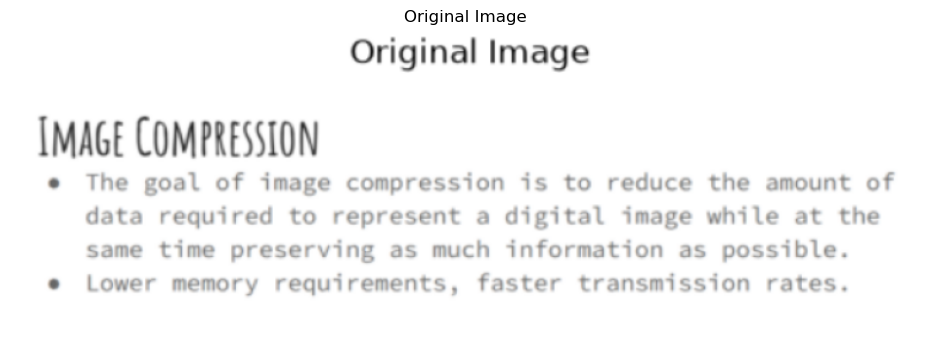

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Read the image
# For demo, create a sample image with text-like patterns if 'PIC.png' doesn't exist
if not os.path.exists('pic.png'):
    # Create a white image with some "handwriting-like" lines
    sample_img = np.ones((400, 600, 3), dtype=np.uint8) * 255
    # Draw some curved lines to simulate handwriting
    for i in range(50, 350, 40):
        pts = np.array([[50, i], [150, i+20], [250, i-10], [350, i+15], [450, i], [550, i+10]], np.int32)
        pts = pts.reshape((-1, 1, 2))
        cv2.polylines(sample_img, [pts], False, (0, 0, 0), 2)
    cv2.imwrite('pic.png', sample_img)

image = cv2.imread('pic.png')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Step 2: Convert to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Step 3: Apply Gaussian blur to reduce noise
blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 0)

# Step 4: Apply adaptive thresholding (better for handwriting than Canny)
# Option A: Simple thresholding
_, thresh = cv2.threshold(blurred_image, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Option B: Canny edge detection (your original approach)
edges = cv2.Canny(blurred_image, 50, 150)

# Step 5: Find contours
# Using thresholded image (usually better for handwriting)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Step 6: Create result_image by copying original and drawing contours
result_image = image.copy()
cv2.drawContours(result_image, contours, -1, (0, 255, 0), 2)  # Green contours

# Step 7: Display all results
plt.figure(figsize=(15, 4))

plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis('off')

(np.float64(-0.5), np.float64(741.5), np.float64(250.5), np.float64(-0.5))

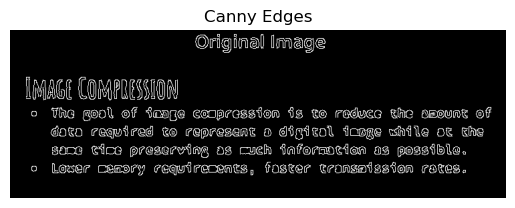

In [22]:
plt.imshow(edges, cmap='gray')
plt.title("Canny Edges")
plt.axis('off')

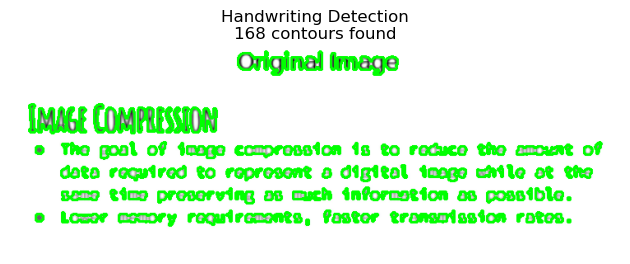

  Handwriting Detection Completed
  Contours detected: 168


In [23]:

plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
plt.title(f"Handwriting Detection\n{len(contours)} contours found")
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"  Handwriting Detection Completed")
print(f"  Contours detected: {len(contours)}")